In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li{font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
table td, th{font-size:16px;}
table{ margin-left:0 !important;   /* 왼쪽 여백 0 */}
</style>
"""))

**<font size="6" color="red">ch1. 허깅페이스 모델 사용</font>**
- Inference API 이용 : 모델의 결과를 server에서
- pipeline() 이용 : 모델을 다운로드 받아 모델의 결과를 local에서 
- 허깅페이스 transformer에서 지원하는 task

| task값 | 설명 |
| :--- | :--- |
| text-classification (별칭 sentiment-analysis) | 감정 분석, 뉴스 분류, 리뷰 분류 등 문장 분류 |
| zero-shot-classification	| 레이블에 대한 별도 학습 없이 후보 레이블 중에서 분류 |
| text-generation	        | GPT 계열 모델을 이용한 텍스트 생성 |
| fill-mask	                | 문장 안의 빈칸(마스크)에 들어갈 단어 예측 |
| ner (token-classification의 별칭) | 개체명 인식(사람, 조직, 장소 등 라벨링) |
| question-answering	    | 주어진 지문(context)을 근거로 질문에 답변 |
| summarization	            | 긴 문서를 짧게 요약 |
| translation	            | 서로 다른 언어 간 번역 |
| image-to-text	            | 이미지 내용을 설명하는 문장 생성 |
| image-classification	    | 이미지가 어떤 대상인지 분류 |


- 처음 모델 사용시 "C:\Users\내컴퓨터이름\.cache\huggingface"에 다운로드되느라 시간이 걸림

In [5]:
import warnings
import os
import logging
 
# 경고 메시지 제거
warnings.filterwarnings('ignore')
 
# transformers 라이브러리의 로깅 레벨을 ERROR로 조정 (경고 숨김)
logging.getLogger("transformers").setLevel(logging.ERROR)
 
# Hugging Face 캐시 관련 symlink 경고 제거
# os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

## 1. 텍스트 기반 감정분석(긍정/부정)
- 토큰화 -> 워드임베딩 -> 모델 -> predict : pipeline()함수는 이 단계를 내부적으로 해 줌

In [3]:
from transformers import pipeline
classifier = pipeline(task="text-classification",
                     model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")
classifier("I've been waiting for a Hugging face course my whole life.")

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9982948899269104}]

In [3]:
# 특정 모델의 파라미터와 용량
from transformers import AutoModel

model = AutoModel.from_pretrained("distilbert/distilbert-base-uncased-finetuned-sst-2-english")

# 전체 파라미터 개수 세기
total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 수: {total_params:,}")
print(f"전체 파라미터 수: {total_params/1024/1024:.3f}MB")

전체 파라미터 수: 66,362,880
전체 파라미터 수: 63.289MB


In [4]:
from transformers import pipeline
classifier = pipeline(task="sentiment-analysis",
                     model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")
# 감정분석할 내용이 많으면 list
classifier([
    "I've been waiting for a Hugging face course my whole life.",
    "I hate this so much!"
])

[{'label': 'POSITIVE', 'score': 0.9982948899269104},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

In [5]:
classifier("이 영화 정말 최고였어요. 감동적이고 연기도 대단해요!")

[{'label': 'POSITIVE', 'score': 0.975276529788971}]

In [6]:
classifier(["I like you", "I hate you", "힘들어요"])

[{'label': 'POSITIVE', 'score': 0.9998695850372314},
 {'label': 'NEGATIVE', 'score': 0.9991129040718079},
 {'label': 'POSITIVE', 'score': 0.8669536709785461}]

In [4]:
classifier = pipeline(task="sentiment-analysis",
                     model="daekeun-ml/koelectra-small-v3-nsmc")
texts = ['힘들어요',"오늘 기분이 최고야", "당신이 싫어요", "난 네가 참 좋아"]
classifier(texts)

Device set to use cpu


[{'label': '0', 'score': 0.9957089424133301},
 {'label': '1', 'score': 0.9973257780075073},
 {'label': '0', 'score': 0.793237566947937},
 {'label': '1', 'score': 0.9590021967887878}]

In [10]:
for text, result in zip(texts, classifier(texts)):
    label = "긍정" if result['label']=='1' else "부정"
    print(f"'{text}' -> {label} {result['score']:.2%}")

'힘들어요' -> 부정 99.57%
'오늘 기분이 최고야' -> 긍정 99.73%
'당신이 싫어요' -> 부정 79.32%
'난 네가 참 좋아' -> 긍정 95.90%


## 2. 제로샷(Zero-shot-분류)
- 제로샷 분류는 기계학습 및 자연어 처리에서 개별 작업에 대한 별도의 학습(파인튜닝) 없이도 분류 작업을 수행할 수 있는 방식이다. 분류하고자 하는 후보 레이블(candidate_labels)만 지정해 주면, 모델이 사전에 학습한 언어 지식을 바탕으로 입력 문장이 어떤 레이블에 가장 가까운지 확률로 계산해 준다

In [3]:
from transformers import pipeline
classifier = pipeline(task='zero-shot-classification',
                     model='facebook/bart-large-mnli')
classifier("I have a probloem with my iphone that needs to be resolved asap!!",
        candidate_labels=['phone', 'urgent','tablet', 'computer'])

Device set to use cpu


{'sequence': 'I have a probloem with my iphone that needs to be resolved asap!!',
 'labels': ['urgent', 'phone', 'computer', 'tablet'],
 'scores': [0.5075375437736511,
  0.4736018776893616,
  0.016088778153061867,
  0.0027717670891433954]}

In [5]:
classifier("This is a course about the Tranformers library.",
          candidate_labels=["education", "business", "phone"])

{'sequence': 'This is a course about the Tranformers library.',
 'labels': ['education', 'business', 'phone'],
 'scores': [0.8320801258087158, 0.09927196800708771, 0.0686478540301323]}

## 3. text 생성
- gpt2 : 파라미터갯수 124,439,808개 
- 모델 용량 : 124,439,808*4 => 118.675MB
- finetuning시 추가메모리 : 학습시 활성화함수, 옵티마이저, 미분 등으로 4배 정도 메모리 필요

In [6]:
# 특정 모델의 파라미터와 용량
from transformers import AutoModel

model = AutoModel.from_pretrained("gpt2")

# 전체 파라미터 개수 세기
total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 수: {total_params:,}")
print(f"전체 파라미터 수: {total_params/1024/1024:.3f}MB")

전체 파라미터 수: 124,439,808
전체 파라미터 수: 118.675MB


In [9]:
generator = pipeline(task="text-generation",
                    model="gpt2")
generator("In this course. We will teach you how to ",
         pad_token_id=generator.tokenizer.eos_token_id)

Device set to use cpu


[{'generated_text': 'In this course. We will teach you how to \xa0use \xa0a \xa0toolbox \xa0to teach you how to build a computer. We will also teach you how to create\xa0 a\xa0 graphical game \xa0to teach you how to create a game with a virtual joystick \xa0to teach you how to create a\xa0 programmable\xa0 game \xa0to teach you how to use a\xa0 game controller \xa0to teach you how to make a\xa0 game \xa0to teach you how to use a\xa0 controller to teach you how to use a\xa0 programmable\xa0 game \xa0to teach you how to use a\xa0 programmable\xa0 game \xa0to teach you how to use a\xa0 programmable\xa0 programmable\xa0 game \xa0to teach you\xa0 about\xa0 how to use a\xa0 programmable\xa0 programmable\xa0 game \xa0to teach you\xa0 about\xa0 how to use a\xa0 programmable\xa0 game \xa0to teach you\xa0 about\xa0 how to use a\xa0 programmable\xa0 game \xa0to teach you\xa0 about\xa0 how to\xa0 use a\xa0 programmable\xa0 programmable\xa0 game \xa0to teach you\xa0 about\xa0 how to\xa0 use a\xa0 p

In [10]:
result = generator("In this course. We will teach you how to ",
         pad_token_id=generator.tokenizer.eos_token_id)
print(result[0]['generated_text'])

In this course. We will teach you how to  produce, produce, and make your own products.
There are many things you can do to make your own products. Here are some of the best:
1) Make a good choice. We will show you how to make a good choice. We will show you how to make a good choice.
Do your best to make the best choices that you can. Don't make the best choices that are not yours.
3) Learn the basics of product production. The basics, if you will, in this course.
4) Learn how to produce and sell products. Learn how to make a good choice.
5) Learn how to create and sell your own products. Learn how to make a good choice.
6) Learn how to make a good choice.
7) Learn how to make a good choice.
8) Make your own products.
9) Learn how to make a good choice.
10) Learn how to make a good choice.
11) Make your own products. Learn how to make a good choice.
12) Learn how to make your own products.
13) Make your own products.
14) Learn how to make your own products.
15) Make your own products.

In [5]:
from transformers import pipeline, set_seed
# set_seed(2)
generator = pipeline("text-generation", "skt/kogpt2-base-v2",
                    device=-1
                    ) # GPU쓰려면 0
prompt = "이 과정은 다음과 같은 것을 알려드려요."
result = generator(prompt,
                  pad_token_id=generator.tokenizer.eos_token_id,
                  max_new_tokens=20, 
                  do_sample=True,     # 샘플링 사용
                  top_k = 50,         # 토큰 후보 폭을 다양하게 확보
                  temperature=0.8,    # 0.2는 너무 보수적, 0.9정도는 유연한 대답
                  top_p = 0.9,        # 상위 90% 누적 확률 토큰만 
                  repetition_penalty=1.2  # 반복적인 단어는 패널티를 
                  )
print(result[0]['generated_text'])

이 과정은 다음과 같은 것을 알려드려요."
"그렇지? 당신들은 뭘 했는가? 그리고 왜 내가 하는 일을 알고


## 4. 마스크 채우기

In [11]:
unmasker = pipeline(task="fill-mask",
                  model="distilbert/distilroberta-base") # 마스크 채우기
unmasker("I'm going to hospital and meet a <mask>", 
        top_k=2
        )

[{'score': 0.19275875389575958,
  'token': 3299,
  'token_str': ' doctor',
  'sequence': "I'm going to hospital and meet a doctor"},
 {'score': 0.06794668734073639,
  'token': 27321,
  'token_str': ' psychiatrist',
  'sequence': "I'm going to hospital and meet a psychiatrist"}]

In [12]:
unmasker("병원에 가서 <mask>를 만날 거예요", top_k=2) # top_k 기본값은 5

[{'score': 0.6820282936096191,
  'token': 1437,
  'token_str': ' ',
  'sequence': '병원에 가서 를 만날 거예요'},
 {'score': 0.04658569023013115,
  'token': 12,
  'token_str': '-',
  'sequence': '병원에 가서-를 만날 거예요'}]

In [ ]:
# unmasker = pipeline("fill-mask", "google-bert/bert-base-uncased")
# unmasker("Hello, I'm a [MASK] model.")

### inference API 이용 
- 모델의 결과를 server에게

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
print(os.getenv('HF_TOKEN')[:2])

hf


In [5]:
from huggingface_hub import InferenceClient
client = InferenceClient(
    provider='hf-inference',
    #api_key=os.getenv('HF_TOKEN')
)
result = client.fill_mask("Hello, I'm a [MASK] model.",
                         model="google-bert/bert-base-uncased",
                         #top_k=2
                         )
result

[FillMaskOutputElement(score=0.1441427320241928, sequence="hello, i ' m a role model.", token=2535, token_str='role', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.14175812900066376, sequence="hello, i ' m a fashion model.", token=4827, token_str='fashion', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.06221463158726692, sequence="hello, i ' m a new model.", token=2047, token_str='new', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.04102848470211029, sequence="hello, i ' m a super model.", token=3565, token_str='super', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.02591117098927498, sequence="hello, i ' m a business model.", token=2449, token_str='business', fill_mask_output_token_str=None)]

In [6]:
[r.sequence for r in result]

["hello, i ' m a role model.",
 "hello, i ' m a fashion model.",
 "hello, i ' m a new model.",
 "hello, i ' m a super model.",
 "hello, i ' m a business model."]

In [10]:
# 다국어 지원되는 mask모델
from transformers import pipeline
unmasker = pipeline("fill-mask", "google-bert/bert-base-multilingual-cased")
result = unmasker("안녕하세요. 나는 [MASK] 모델입니다", top_k=3)

Some weights of the model checkpoint at google-bert/bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [12]:
[r['sequence'] for r in result]

['안녕하세요. 나는 가수 모델입니다', '안녕하세요. 나는 여자 모델입니다', '안녕하세요. 나는 프로 모델입니다']

## 5. 개체명 인식(NER ; Named Entity Recognition)

In [15]:
ner = pipeline("ner", 
               "dbmdz/bert-large-cased-finetuned-conll03-english",
              grouped_entities=True) # 객체들을 그룹으로 묶을지 말지
ner("My name is Sylvain and I work at Hugging Face in Brooklyn.")

[{'entity_group': 'PER',
  'score': np.float32(0.9981694),
  'word': 'Sylvain',
  'start': 11,
  'end': 18},
 {'entity_group': 'ORG',
  'score': np.float32(0.9796019),
  'word': 'Hugging Face',
  'start': 33,
  'end': 45},
 {'entity_group': 'LOC',
  'score': np.float32(0.9932106),
  'word': 'Brooklyn',
  'start': 49,
  'end': 57}]

## 6. 질의응답
- context에 대한 질의 응답

In [20]:
question_answer = pipeline("question-answering")
# question-answering 타스크의 기본 모델 : distilbert/distilbert-base-cased-distilled-squad
question_answer(
    question="Where do I work?",
    context="My name is Sylvain and I work at Hugging Face in Brooklyn."
) #context 지문을 이용해서 답을 하는 것

{'score': 0.6385914087295532, 'start': 33, 'end': 45, 'answer': 'Hugging Face'}

In [18]:
context = "My name is Sylvain and I work at Hugging Face in Brooklyn."
context[33:45]

'Hugging Face'

## 7. 문서요약
- torch 버전 2.6보다 낮으면 문서요약 안 될 수 있음

In [22]:
summarizer = pipeline("summarization",
                     "facebook/bart-large-cnn")
summarizer('''Goyang City in Gyeonggi announced today (the 10th) that it will push forward with remodeling 
Goyang Sports Complex, which has been completed for more than 20 years.
As large-scale performances have recently increased in frequency and thus become more 
widely used, the judgment is that there is a need to comprehensively improve safety, 
user convenience, and operational efficiency.
The city’s plan goes beyond simply repairing aging facilities, aiming to comprehensively 
enhance the venue’s use by integrating its functions as a performance center, sports venue, 
and tourist attraction.
Opened in September 2003, Goyang Sports Complex is a multipurpose stadium with a total area 
of 60,461 square meters and 40,907 seats.
Equipped with a natural grass field and track, it served as Goyang’s flagship sports 
infrastructure by hosting major international events such as the 2014 Incheon Asian 
Games and the 2022 Qatar World Cup qualifiers, but it was not fully utilized for quite 
some time.
Recently, performances by top-tier artists both in Korea and abroad, such as Coldplay, 
BTS, Big Bang, and Blackpink, have been held one after another, and the venues are once 
again filling up with tens of thousands of spectators.
At the same time, the need to improve viewing environments, safety, and convenience to 
meet the increased demand is also growing.''',
          max_length=130, 
          min_length=30,
          do_sample=True)

[{'summary_text': 'Goyang City in Gyeonggi announced today (the 10th) that it will push forward with remodeling Goyang Sports Complex. The city’s plan goes beyond simply repairing aging facilities, aiming to integrate its functions as a performance center, sports venue, and tourist attraction.'}]

## 8. 번역

In [25]:
# pip install sacremoses
translator = pipeline('translation',
                     'Helsinki-NLP/opus-mt-fr-en') # 프랑스어 -> 영어

In [26]:
translator('Ce cours est produit par Hugging Face.')

[{'translation_text': 'This course is produced by Hugging Face.'}]

In [31]:
# 한->영
ko2en = pipeline("translation", model="Helsinki-NLP/opus-mt-ko-en")
# 영->한(불량)
en2ko = pipeline("translation", model="Helsinki-NLP/opus-mt-tc-big-en-ko")
# 테스트 문장
ko_sentence = "이 문장을 영어로 번역해 주세요"
en_sentence = "I enjoy learning about AI"
# 번역
print('한->영 :', ko2en(ko_sentence)[0]['translation_text'])
print('영->한 :', en2ko(en_sentence)[0]['translation_text'])

한->영 : Please translate this sentence into English.
영->한 : US  풍선 행


In [33]:
result = ko2en([
    '안녕하세요? 즐거운 하루 보내세요',
    '내일부터는 open ai API를 나갑니다',
    '결제를 위해서 직불카드 지참바랍니다'
])
[r['translation_text'] for r in result]

['Hello? Have a good day.',
 'Tomorrow, we go to the Open ai APl.',
 "I hope you don't have a direct card for the payment."]

## 9. 이미지를 설명하는 텍스트 생성

<class 'numpy.ndarray'> (512, 768)


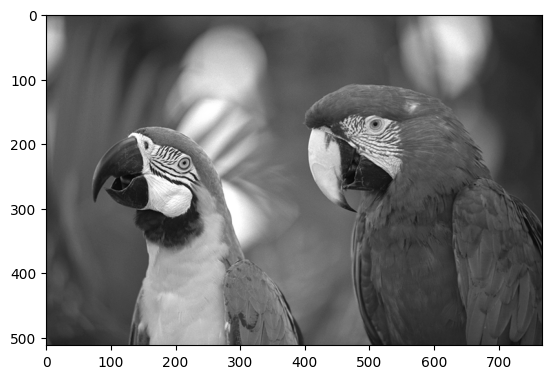

In [3]:
url = 'https://huggingface.co/datasets/Narsil/image_dummy/resolve/main/parrots.png'
from PIL import Image
import requests
import numpy as np
response = requests.get(url, stream=True).raw
image = Image.open(response)
# image = image.resize((150,150))
image_npy = np.array(image)
print(type(image_npy), image_npy.shape)
import matplotlib.pyplot as plt
plt.imshow(image_npy, cmap='gray')

In [6]:
from transformers import pipeline
imagetotext = pipeline("image-to-text",
                      "ydshieh/vit-gpt2-coco-en")
imagetotext(url, max_new_tokens=30) # 30토큰 내로 설명

[{'generated_text': 'two birds are standing next to each other '}]

In [8]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
response = requests.get(url, stream=True).raw
image = Image.open(response)
imagetotext(url, max_new_tokens=50)

[{'generated_text': 'a cat laying on a blanket next to a cat laying on a bed '}]

In [10]:
filename = 'images/fb.jpg'
# Image.open(filename) : 파일 내용
imagetotext(filename, max_new_tokens=50)

[{'generated_text': 'a variety of fruits and vegetables are displayed on a table '}]

## 10. 이미지분류

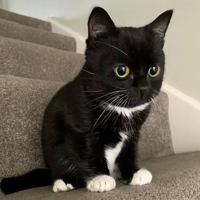

In [14]:
image = Image.open('images/cat.jpg')
image.resize((200,200))

In [16]:
imgclassifier = pipeline("image-classification",
                        "google/vit-base-patch16-224")
imgclassifier(image)

[{'label': 'Egyptian cat', 'score': 0.853131890296936},
 {'label': 'tabby, tabby cat', 'score': 0.04750380292534828},
 {'label': 'tiger cat', 'score': 0.03486618399620056},
 {'label': 'Persian cat', 'score': 0.007555846590548754},
 {'label': 'Siamese cat, Siamese', 'score': 0.003788588335737586}]